#**🏆** Mini Challenge: Data Cleanup - Tweet Dataset (Darija)



📌 Challenge Description:

In this challenge, you will clean a tweet dataset from Hugging Face (`shmuhammad/AfriSenti-twitter-sentiment`), focusing on the Moroccan Darija subset. The goal is to preprocess the text data by removing emojis, usernames, and applying [texte du lien](https://)a custom list of Darija stop words. The cleaned data will then be ready for n-gram analysis.

📊 Dataset Summary:
AfriSenti is the largest sentiment analysis dataset for under-represented African languages, covering 110,000+ annotated tweets in 14 African languages (Amharic, Algerian Arabic, Hausa, Igbo, Kinyarwanda, Moroccan Arabic, Mozambican Portuguese, Nigerian Pidgin, Oromo, Swahili, Tigrinya, Twi, Xitsonga, and Yoruba).

# Part 1: Data Cleaning

In [60]:
#Installing Necessary Packages
!pip install datasets pandas regex


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [61]:
!pip install -q "datasets<4.0.0" pandas regex


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [62]:
#Import Necessary Packages
from  datasets  import load_dataset
import pandas as pd
import re

## Load the Dataset

In [63]:
import requests

# Télécharger le fichier .txt depuis GitHub
url = "https://raw.githubusercontent.com/zerouani/darija-stop-words/main/stopwords.txt"
response = requests.get(url)

# Sauvegarder en .csv 
with open("darija_stop_words.csv", "w", encoding="utf-8") as f:
    f.write("word\n")             
    f.write(response.text)         

print(" Fichier darija_stop_words.csv créé avec succès")

 Fichier darija_stop_words.csv créé avec succès


In [64]:
"""
Load the `shmuhammad/AfriSenti-twitter-sentiment` dataset from the Hugging Face `datasets` library for Moroccan Darija.
"""
darija_stop_words_df = pd.read_csv("./darija_stop_words.csv")
darija_stop_words = darija_stop_words_df['word'].tolist()


In [65]:
# dataset tweets darija
darija_dataset = load_dataset("shmuhammad/AfriSenti-twitter-sentiment", "ary", trust_remote_code=True)

In [66]:
""" Identify and select the subset of tweets of the train datasets"""
darija_dataset_df = pd.DataFrame(darija_dataset['train'])

## Remove Emojis From Tweets

In [67]:
def remove_emojis(tweet):
    emoj = re.compile("["
       u"\U0001F600-\U0001F64F"  # emoticons
       u"\U0001F300-\U0001F5FF"  # symbols & pictographs
       u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                      u"\U0001F923"
                      u"\U0001F97A"
                      u"\U0001F914""]+", re.UNICODE)
    return re.sub(emoj ,'', tweet)

You can use this ressource emojis unicode: https://apps.timwhitlock.info/emoji/tables/unicode

In [68]:
# remove the emojis from the dataset
darija_dataset_df['tweet'] = darija_dataset_df['tweet'].apply(remove_emojis)

In [69]:
darija_dataset_df.head()

,tweet,label
0,hhhhhhhhhhhhhhhhhhhhhh ana ga3ma sma3tt ach ka...,1
1,hhhh hardart jomhorha la fi3lan kadahko lach m...,1
2,: أتفهم العثماني وأتفهم الجدل الشعبي. الحل: حا...,1
3,كان افظل حاكم عربي',0
4,ماريانو راخوي : خاص المغرب واسبانيا يشرحو للرأ...,1


## Remove user name from tweets

In [70]:
def remove_user(tweet):
    user_re =  "@[A-Za-z0-9]+"
    return re.sub(user_re, ' ', tweet)

In [71]:
#remove the user names from the dataset
darija_dataset_df['tweet'] = darija_dataset_df['tweet'].apply(remove_user)

In [ ]:
darija_dataset_df.sample(10)
darija_dataset_df.info

<bound method DataFrame.info of                                                   tweet  label
0     hhhhhhhhhhhhhhhhhhhhhh ana ga3ma sma3tt ach ka...      1
1     hhhh hardart jomhorha la fi3lan kadahko lach m...      1
2     : أتفهم العثماني وأتفهم الجدل الشعبي. الحل: حا...      1
3                                   كان افظل حاكم عربي'      0
4     ماريانو راخوي : خاص المغرب واسبانيا يشرحو للرأ...      1
...                                                 ...    ...
5578            wah akhouya titiz o dikchi 3la 9ad lhal      1
5579  soukaina dik nhar drt follow haydato o 9lt f k...      1
5580                kiban liya stormy kid7ak mn hna ana      1
5581            woww ghadi tefra7 bzzf thank uu aaliaaa      0
5582  الواقع وهوأن هؤلاء دخلوا مستنقعا لن يخرجوا منه...      2

[5583 rows x 2 columns]>

## Remove latin letter

In [73]:
def remove_latin(tweet):
    latin_re =  "[A-Za-z]+"
    return re.sub(latin_re, ' ', tweet)

In [74]:
#remove latin words
darija_dataset_df['tweet'] = darija_dataset_df['tweet'].apply(remove_latin)

## Removing Dublicate Rows

In [75]:
darija_dataset_df.drop_duplicates(inplace = True)
darija_dataset_df

,tweet,label
0,3 3 9 3,1
1,3 3 3,1
2,: أتفهم العثماني وأتفهم الجدل الشعبي. الحل: حا...,1
3,كان افظل حاكم عربي',0
4,ماريانو راخوي : خاص المغرب واسبانيا يشرحو للرأ...,1
...,...,...
5578,3 9,1
5579,9,1
5580,7,1
5581,7,0


## Remove Punctuation

In [76]:
import re
def remove_ponct(tweet):
    ponct_re =  "[^\w\s]+"
    return re.sub(ponct_re, ' ', tweet)

<>:3: SyntaxWarning: invalid escape sequence '\w'
<>:3: SyntaxWarning: invalid escape sequence '\w'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23640\878315859.py:3: SyntaxWarning: invalid escape sequence '\w'
  ponct_re =  "[^\w\s]+"


In [77]:
#remove ponctuation
darija_dataset_df['tweet'] = darija_dataset_df['tweet'].apply(remove_ponct)

## Tokenization

In [78]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')
def Tokenize(tweet):
    return word_tokenize(tweet)

darija_dataset_df["tweet_token"] = darija_dataset_df['tweet'].apply(Tokenize)
darija_dataset_df.head()

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,tweet,label,tweet_token
0,3 3 9 3,1,"[3, 3, 9, 3]"
1,3 3 3,1,"[3, 3, 3]"
2,أتفهم العثماني وأتفهم الجدل الشعبي الحل حا...,1,"[أتفهم, العثماني, وأتفهم, الجدل, الشعبي, الحل,..."
3,كان افظل حاكم عربي,0,"[كان, افظل, حاكم, عربي]"
4,ماريانو راخوي خاص المغرب واسبانيا يشرحو للرأ...,1,"[ماريانو, راخوي, خاص, المغرب, واسبانيا, يشرحو,..."


## Remove Stops Words


In [79]:
#Import darija stopwords dataset
# the darija stop words will be found here https://github.com/zerouani/darija-stop-words/blob/main/stopwords.txt, change the extension and the head name
darija_stop_words_df = pd.read_csv("./darija_stop_words.csv")
darija_stop_words = darija_stop_words_df['word'].tolist()

In [80]:
def remove_stop(all_tokens, stop_lst):
    stop_lst = {stp_wrd.strip() for stp_wrd in stop_lst}  # Convert stop_lst to a set for faster lookups
    return [token.strip() for token in all_tokens if token.strip() not in stop_lst]

In [81]:
#remove darija stopwords
darija_dataset_df['tweet_token'] = darija_dataset_df['tweet_token'].apply(remove_stop, args=(darija_stop_words,),)

In [82]:
all_token = [token for list_token in darija_dataset_df['tweet_token'] for token in list_token]

# Part 2: N-Grams Analysis

In [83]:
#Install Necessary Librairies
!pip install nltk pandas matplotlib seaborn wordcloud networkx arabic-reshaper python-bidi

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Unigrams

In [84]:
from collections import Counter
unigram_counts = Counter(all_token)

## Barplot of Unigrams

In [85]:
#Import Necessary Packages
import matplotlib.pyplot as plt
import seaborn as sns
import arabic_reshaper
from bidi.algorithm import get_display

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23640\3839270694.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=bidi_words, palette="viridis")
C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


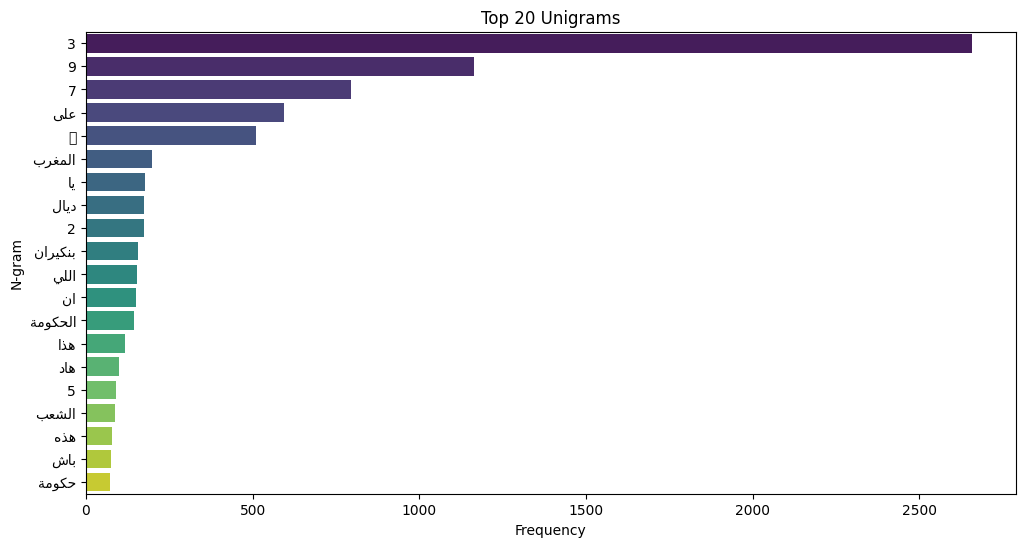

In [86]:
def plot_top_n_grams(ngram_counts, n, title):
    top_n = ngram_counts.most_common(n)
    words, counts = zip(*top_n)
    plt.figure(figsize=(12, 6))
    reshaped_words = [arabic_reshaper.reshape(word) for word in words]
    bidi_words = [get_display(word) for word in reshaped_words]
    sns.barplot(x=list(counts), y=bidi_words, palette="viridis")
    plt.title(f"Top {n} {title}")
    plt.xlabel("Frequency")
    plt.ylabel("N-gram")
    plt.show()

plot_top_n_grams(unigram_counts, 20, "Unigrams")

## WordCloud

In [87]:
#Import Necessary Librairies
import matplotlib.pyplot as plt
from wordcloud import WordCloud

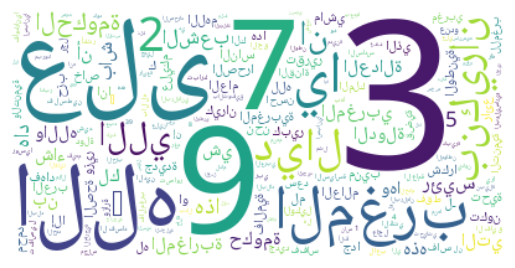

In [88]:
# download the ttf file from this website: https://arbfonts.com/noto-naskh-arabic-regular-font-download.html
cloud_ar = WordCloud(font_path='NotoNaskhArabic-VariableFont_wght.ttf', background_color="white").generate_from_frequencies(unigram_counts)
plt.imshow(cloud_ar, interpolation='bilinear')
plt.axis('off')

plt.savefig("ary")
plt.show()